# APs Preprocessing

## Read the data

In [1]:
SAVE_PREPROCESSED_FILES = True

In [2]:
import spikeinterface.full as si

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

spikeglx_folder = Path('//132.66.34.210/Pixel1/1_auditory_neuropixels_BarakH/20240319_C9_T2_NP2_-10dB_g0')

stream_names, stream_ids = si.get_neo_streams('spikeglx', spikeglx_folder)

## stream_names = ['imec0.ap', 'nidq', 'imec0.lf']

# NI_rec = si.read_spikeglx(spikeglx_folder, stream_name='nidq', load_sync_channel=True)
AP_rec = si.read_spikeglx(spikeglx_folder, stream_name='imec0.ap', load_sync_channel=False)
# LFP_rec = si.read_spikeglx(spikeglx_folder, stream_name='imec0.lf', load_sync_channel=True)

In [3]:
# print(f'NI (with sync channel)- {NI_rec}')
print(f'AP (without sync channel)- {AP_rec}')
# print(f'LFP (with sync channel)- {LFP_rec}')

AP (without sync channel)- SpikeGLXRecordingExtractor: 384 channels - 30000.129289 Hz - 1 segments - 224,403,517 samples 
                            7,480.08s (2.08 hours) - int16 dtype - 160.51 GiB


## Probe layout

In [4]:
AP_rec.get_probe().to_dataframe()

,x,y,contact_shapes,width,shank_ids,contact_ids
0,16.0,0.0,square,12.0,,e0
1,48.0,0.0,square,12.0,,e1
2,0.0,20.0,square,12.0,,e2
3,32.0,20.0,square,12.0,,e3
4,16.0,40.0,square,12.0,,e4
...,...,...,...,...,...,...
379,32.0,3780.0,square,12.0,,e379
380,16.0,3800.0,square,12.0,,e380
381,48.0,3800.0,square,12.0,,e381
382,0.0,3820.0,square,12.0,,e382


(-100.0, 100.0)

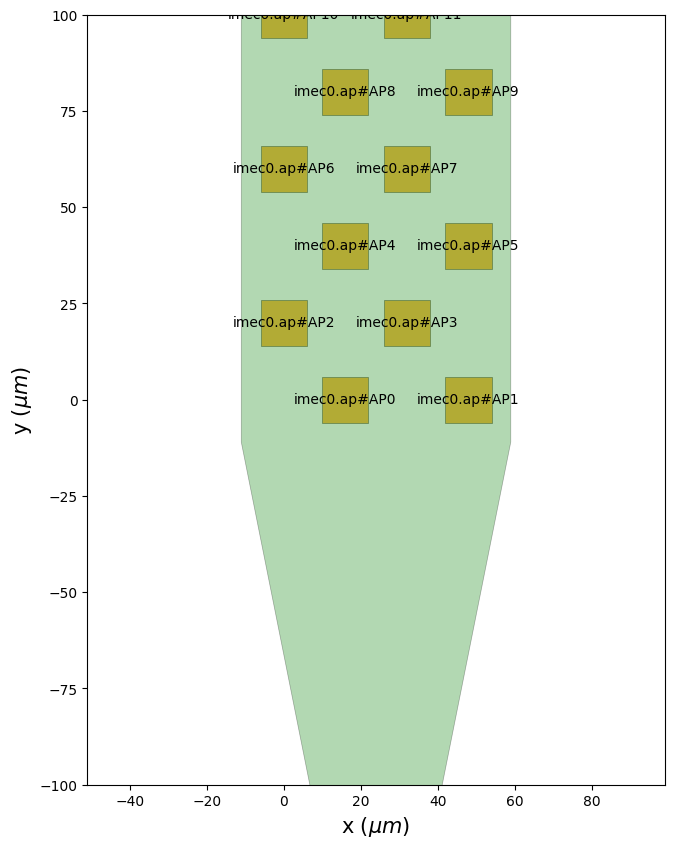

In [5]:
fig, ax = plt.subplots(figsize=(15, 10))
si.plot_probe_map(AP_rec, ax=ax, with_channel_ids=True)
ax.set_ylim(-100, 100)

## Preprocess the recording
- Common_reference() all channels (equivalent to CATGT).

In [6]:
rec1 = si.highpass_filter(AP_rec, freq_min=400.)
bad_channel_ids, channel_labels = si.detect_bad_channels(rec1)
rec2 = rec1.remove_channels(bad_channel_ids)
print('bad_channel_ids', bad_channel_ids)

rec3 = si.phase_shift(rec1)
rec4 = si.common_reference(rec3, operator="median", reference="global")
rec = rec4
rec

KeyboardInterrupt: 

## Visualize the preprocessing steps

In [ ]:
# here we use static plot using matplotlib backend
fig, axs = plt.subplots(ncols=4, figsize=(10, 5))

si.plot_traces(AP_rec, backend='matplotlib',  clim=(-50, 50), ax=axs[0])
si.plot_traces(rec1, backend='matplotlib',  clim=(-50, 50), ax=axs[1])
si.plot_traces(rec2, backend='matplotlib',  clim=(-50, 50), ax=axs[2])
si.plot_traces(rec, backend='matplotlib',  clim=(-50, 50), ax=axs[3])

for i, label in enumerate(('Raw', 'Filter', 'Remove Bad', 'Final')):
    axs[i].set_title(label)

# plot some channels
fig, ax = plt.subplots(figsize=(10, 5))
some_chans = rec.channel_ids[[100, 140, 200]]
si.plot_traces({'filter':rec1, 'cmr': rec4}, backend='matplotlib', mode='line', ax=ax, channel_ids=some_chans)

## Save the preprocessed data
(Only because the sorter needs it saved - very slow and costly)

In [ ]:
if SAVE_PREPROCESSED_FILES:
    job_kwargs = dict(n_jobs=20, chunk_duration='4s', progress_bar=True)

    save_preprocess_path = Path('G:/')
    rec = rec.save(folder=save_preprocess_path / f'{spikeglx_folder.name}/preprocess', format='binary', **job_kwargs, overwrite=True)

In [ ]:
# our recording now points to the new binary folder
rec

## Check spiking activity and drift before spike sorting
- Estimate the noise levels
- Detect peaks (prior to sorting)
- Estimate positions of peaks

### Check noise level


In [ ]:
# we can estimate the noise on the scaled traces (microV) or on the raw one (which is in our case int16).
noise_levels_microV = si.get_noise_levels(rec, return_scaled=True)
noise_levels_int16 = si.get_noise_levels(rec, return_scaled=False)

In [ ]:
fig, ax = plt.subplots()
_ = ax.hist(noise_levels_microV, bins=np.arange(5, 30, 2.5))
ax.set_xlabel('noise  [microV]')

### Detect and localize peaks

In [ ]:
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

job_kwargs = dict(n_jobs=40, chunk_duration='1s', progress_bar=True)
peaks = detect_peaks(rec,  method='locally_exclusive', noise_levels=noise_levels_int16,
                     detect_threshold=5, radius_um=50., **job_kwargs)
peaks

In [ ]:
from spikeinterface.sortingcomponents.peak_localization import localize_peaks

job_kwargs = dict(n_jobs=10, chunk_duration='1s', progress_bar=True)
peak_locations = localize_peaks(rec, peaks, method='center_of_mass', radius_um=50., **job_kwargs)

#### Check for drifts

In [ ]:
# check for drifts
fs = rec.sampling_frequency
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(peaks['sample_index'] / fs, peak_locations['y'], color='k', marker='.',  alpha=0.002)

In [ ]:
# we can also use the peak location estimates to have an insight of cluster separation before sorting
fig, ax = plt.subplots(figsize=(15, 10))
si.plot_probe_map(rec, ax=ax, with_channel_ids=True)
ax.set_ylim(-100, 400)

ax.scatter(peak_locations['x'], peak_locations['y'], color='purple', alpha=0.002)